In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text

In [2]:
df=pd.read_csv("../data/processed/insurance_claims_interpretable.csv")
df.head()

,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,...,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,age_semantic,claim_semantic,months_as_customer_semantic
0,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,...,6510,13020,52080,Saab,92x,2004,Y,Adulto_Esperto,Danno_Estremo,Cliente_Storico
1,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,...,780,780,3510,Mercedes,E400,2007,Y,Giovane_Adulto,Danno_Moderato,Cliente_Storico
2,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,...,7700,3850,23100,Dodge,RAM,2007,N,Giovane_Adulto,Danno_Moderato,Cliente_Storico
3,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,...,6340,6340,50720,Chevrolet,Tahoe,2014,Y,Giovane_Adulto,Danno_Estremo,Cliente_Storico
4,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,...,1300,650,4550,Accura,RSX,2009,N,Giovane_Adulto,Danno_Moderato,Cliente_Storico


In [3]:
from sklearn.preprocessing import StandardScaler


X=df.drop(columns=["fraud_reported"])
Y=df["fraud_reported"].apply(lambda x: 1 if x=="Y" else 0)

numeric_features=X.select_dtypes(include=["int64","float64"]).columns
scaler=StandardScaler()
X[numeric_features]=scaler.fit_transform(X[numeric_features])

X_encoded=pd.get_dummies(X)
X_train,X_test,y_train,y_test=train_test_split(X_encoded,Y,test_size=0.2,random_state=42)

In [4]:
from sklearn.ensemble import RandomForestClassifier


rf_clf=RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_clf.fit(X_train,y_train)
print("Modello Random Forest addestrato con successo!")

Modello Random Forest addestrato con successo!


Prendiamo le 3 variabili che avevano maggiore incidenza nelle classificazioni di prima

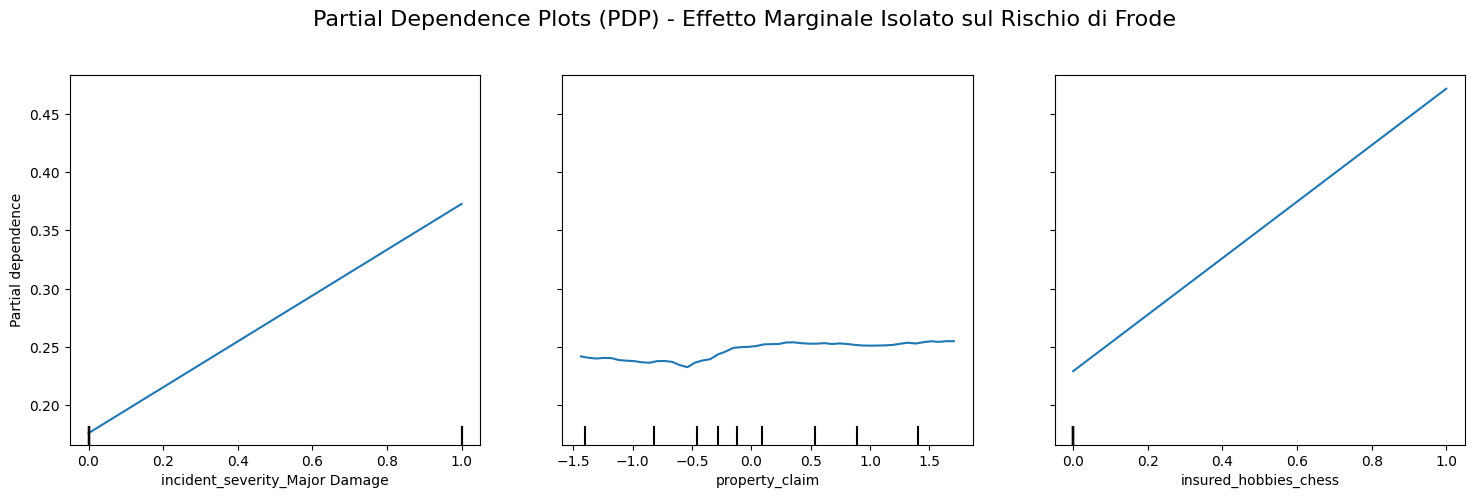

In [7]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features_to_plot = [
    'incident_severity_Major Damage', 
    'property_claim', 
    'insured_hobbies_chess' 
]

fig,ax=plt.subplots(figsize=(18,5))
display=PartialDependenceDisplay.from_estimator(
    estimator=rf_clf,
    X=X_train,
    features=features_to_plot,
    ax=ax,
    kind="average",
    grid_resolution=50
)
fig.suptitle("Partial Dependence Plots (PDP) - Effetto Marginale Isolato sul Rischio di Frode", fontsize=16)
plt.subplots_adjust(top=0.85)
plt.show()

In [8]:
from sklearn.inspection import permutation_importance
print("Calcolo della Permutation Feature Importance in corso...")

result=permutation_importance(rf_clf,X_test,y_test,n_repeats=10,random_state=42,n_jobs=-1)

pfi_importances=pd.Series(result.importances_mean,index=X_test.columns)

Calcolo della Permutation Feature Importance in corso...


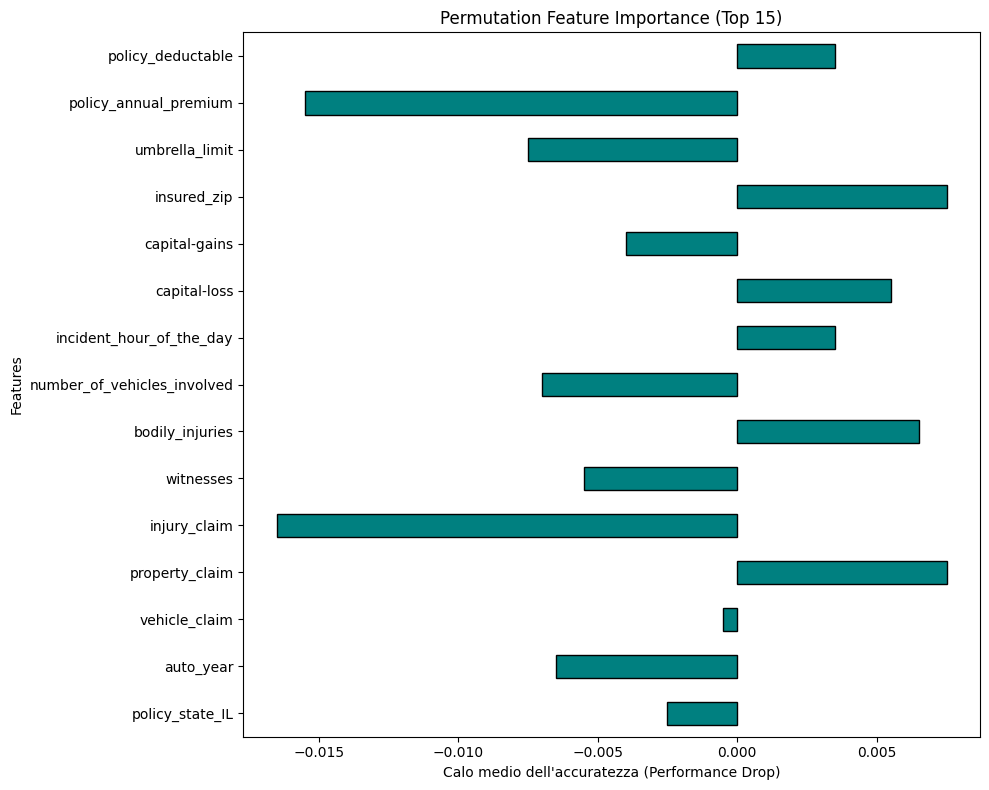

TOP FEATURE PIÙ IMPORTANTI (PFI)
policy_deductable: 0.0035
policy_annual_premium: -0.0155
umbrella_limit: -0.0075
insured_zip: 0.0075
capital-gains: -0.0040
capital-loss: 0.0055
incident_hour_of_the_day: 0.0035
number_of_vehicles_involved: -0.0070
bodily_injuries: 0.0065
witnesses: -0.0055


In [9]:
pfi_importances_sorted = pfi_importances.sort_values(ascending=False)
top_features=pfi_importances.head(15)
fig, ax = plt.subplots(figsize=(10, 8))
top_features.plot.barh(ax,ax,color='teal',edgecolor='black')
ax.set_title("Permutation Feature Importance (Top 15)")
ax.set_xlabel("Calo medio dell'accuratezza (Performance Drop)")
ax.set_ylabel("Features")
ax.invert_yaxis()  # Capovolge l'asse Y per avere la più importante in alto
plt.tight_layout()
plt.show()

print("TOP FEATURE PIÙ IMPORTANTI (PFI)")
for feature,importance in top_features.head(10).items():
    print(f"{feature}: {importance:.4f}")